#### Accuracy comparison between LLM and XGBoost 

& text & 0.82 & 0.93 \\
& entity & 0.80 & 0.91 \\
& time & 0.90 & 0.99 \\
& quantity & 0.85 & 0.99 \\
& globecoordinate & 0.75 & 0.94 \\


/tmp/ipykernel_3677835/2945622872.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks().round(2), fontsize=8)


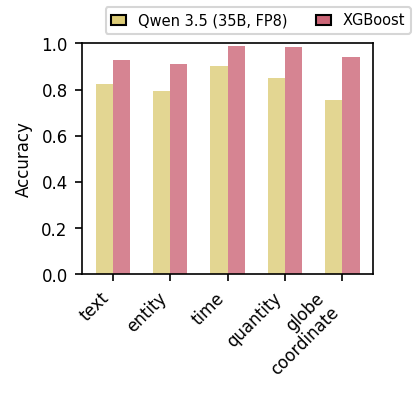

In [2]:
import json
import pickle
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

with open('src/results/training/best_model_training_info.pkl', 'rb') as f:
    best_model = pickle.load(f)

# have f1, acc, prec, rec per datatype
avg_best_model = {}
for datatype, training_info in best_model.items():
    
    micro_average = training_info['micro_averages']
    sum_f1 = 0
    sum_prec = 0
    sum_acc = 0
    sum_rec = 0
    for label, metrics in micro_average.items():

        sum_f1 += metrics['f1']
        sum_acc += metrics['accuracy']
        sum_prec += metrics['precision']
        sum_rec += metrics['recall']

    avg_rec = sum_rec / len(micro_average.keys())
    avg_acc = sum_acc / len(micro_average.keys())
    avg_prec = sum_prec / len(micro_average.keys())
    avg_f1 = sum_f1 / len(micro_average.keys())

    avg_best_model[datatype] = {'avg_f1': avg_f1, 'avg_rec': avg_rec, 'avg_acc': avg_acc, 'avg_prec': avg_prec}

with open('src/results/classification/llm_classification.json', 'r') as f:
    results_llm = json.load(f)['llm']

avg_metrics_llm = {}
for datatype, metrics_label in results_llm.items():
    sum_f1 = 0
    sum_prec = 0
    sum_acc = 0
    sum_rec = 0
    
    for label, metrics in metrics_label.items():
        sum_f1 += metrics['f1']
        sum_acc += metrics['accuracy']
        sum_prec += metrics['precision']
        sum_rec += metrics['recall']

    avg_rec = sum_rec / len(metrics_label.keys())
    avg_acc = sum_acc / len(metrics_label.keys())
    avg_prec = sum_prec / len(metrics_label.keys())
    avg_f1 = sum_f1 / len(metrics_label.keys())

    avg_metrics_llm[datatype] = {'avg_f1': avg_f1, 'avg_rec': avg_rec, 'avg_acc': avg_acc, 'avg_prec': avg_prec}

color_palette = [
    '#4477AA', '#88CCEE', '#117733', '#DDCC77', '#CC6677', 
    '#AA4499', '#332288', '#6699CC', '#44AA99', 
    '#117733', '#999933', '#661100', '#882255' 
]

clear_color_palette = ['#88CCEE', '#DDCC77', '#CC6677', '#44AA99', '#999933', '#6699CC']

datatypes = ['text', 'entity', 'time', 'quantity']
fig, ax = plt.subplots(figsize=(2.5,2), dpi=150)
width = 0.3
for idx, datatype in enumerate(datatypes):
    values_llm_f1 = avg_metrics_llm[datatype]['avg_f1']
    values_llm_acc = avg_metrics_llm[datatype]['avg_acc']
    
    values_ml_trad_f1 = avg_best_model[datatype]['avg_f1']
    values_ml_trad_acc = avg_best_model[datatype]['avg_acc']

    print(f"& {datatype} & {values_llm_acc:.2f} & {values_ml_trad_acc:.2f} \\\\")

    # bars_f1_llm = ax.bar(idx, values_llm_f1, width, label='LLM', alpha=0.8)
    # bars_f1_ml = ax.bar(idx, values_ml_trad_f1, width, label='XGB', alpha=0.8)

    bars_acc_llm = ax.bar(idx, values_llm_acc, width, alpha=0.8, color=clear_color_palette[1])
    bars_acc_ml = ax.bar(idx + width, values_ml_trad_acc, width, alpha=0.8, color=clear_color_palette[2])

#  average globecoordinate
values_llm_acc = (avg_metrics_llm['globecoordinate_latitude']['avg_acc'] + avg_metrics_llm['globecoordinate_longitude']['avg_acc'])/2
values_ml_trad_acc = (avg_best_model['globecoordinate_latitude']['avg_acc'] + avg_best_model['globecoordinate_longitude']['avg_acc'])/2
print(f"& globecoordinate & {values_llm_acc:.2f} & {values_ml_trad_acc:.2f} \\\\")
bars_acc_llm = ax.bar(len(datatypes), values_llm_acc, width, alpha=0.8, color=clear_color_palette[1])
bars_acc_ml = ax.bar(len(datatypes) + width, values_ml_trad_acc, width, alpha=0.8, color=clear_color_palette[2])

datatypes += ['globe\ncoordinate']
ax.set_ylabel('Accuracy', fontsize=8)
ax.set_ylim(0, 1)
ax.set_yticklabels(ax.get_yticks().round(2), fontsize=8)

x_ticks_pos = [idx + 0.15 for idx, _ in enumerate(datatypes)]
ax.set_xticks(x_ticks_pos)
labels = []
for datatype in datatypes:
    labels.append(datatype.replace("_", "\n"))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
legend_elements = [
    Patch(facecolor=clear_color_palette[1], edgecolor='black', label='Qwen 3.5 (35B, FP8)'),
    Patch(facecolor=clear_color_palette[2], edgecolor='black', label='XGBoost'),
]
fig.legend(handles=legend_elements, ncol=len(legend_elements), loc='outside upper right', fontsize=7, markerscale=0.04, handlelength=1)

#### Micro average -  Data structure

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

"""
training_info_{model}.pkl structure:
{
    "datatype": { # for reverted_edit & property_replacement, datatype is the name of the label
        'results_folds': [results per fold],
        'micro_averages': {}
    ...
}

results per fold:
{
    'classifier': string, # kn, xgboost, random_forest, gradient_boosting
    'fold': int,
    'metrics_results': {
        'label': { 
            'precision': float,
            'recall': float,
            'accuracy': float,
            'f1': float
        },
        ....
    },
    'model': clf,
    'base_model': model,
    'features': feature_cols,
    ....
}

'micro_averages': {
    'label' : {
        'precision': precision_value,
        'f1': ...,
        'recall': ...,
        'accuracy': .... 
    }
}

Final structure to save:
"model": {
    "datatype":{
        "label": {
            "precision": float,
            "recall": float,
            "accuracy": float,
            "f1": float
        }
    }
}
"""

# Create data structure
results = {}
for model in ['kn', 'random_forest', 'gradient_boosting', 'xgboost']:
    print(f'Processing model: {model}')
    with open(f'src/classifiers/ml/training_info/training_info_{model}.pkl', 'rb') as f:
        training_info_model = pickle.load(f)
    
    results[model] = {}
    
    # go over each fold's results for a single datatype
    for datatype, training_info in training_info_model.items():
        
        micro_averages = training_info['micro_averages']

        results[model][datatype] = {}
    
        overall_accuracy_all_folds = {}
        overall_precision_all_folds = {}
        overall_recall_all_folds = {}
        overall_f1_all_folds = {}

        for label, metric_values in micro_averages.items(): # metric values across all folds

            results[model][datatype][label] = {
                'precision': metric_values['precision'],
                'recall': metric_values['recall'],
                'accuracy': metric_values['accuracy'],
                'f1': metric_values['f1']
            }

# print('results for random_forest entity refinement:')
# print(results['random_forest']['entity']['refinement'])

# re-order data structure for visualization

"""
Structure for visualization:
"datatype": {
    "label": {
        "model": {
            "precision": float,
            "recall": float,
            "accuracy": float,
            "f1": float
        }
    }
}
"""

results_dt_label_model_micro = {}
for model in results:
    for datatype in results[model]:
        if datatype not in results_dt_label_model_micro:
            results_dt_label_model_micro[datatype] = {}
        
        for label in results[model][datatype]:
            if label not in results_dt_label_model_micro[datatype]:
                results_dt_label_model_micro[datatype][label] = {}
            
            results_dt_label_model_micro[datatype][label][model] = results[model][datatype][label]

# print('results for random_forest entity refinement:')
# print(results_dt_label_model['entity']['refinement']['random_forest'])


Processing model: kn
Processing model: random_forest
Processing model: gradient_boosting
Processing model: xgboost


### Comparison of different classifiers

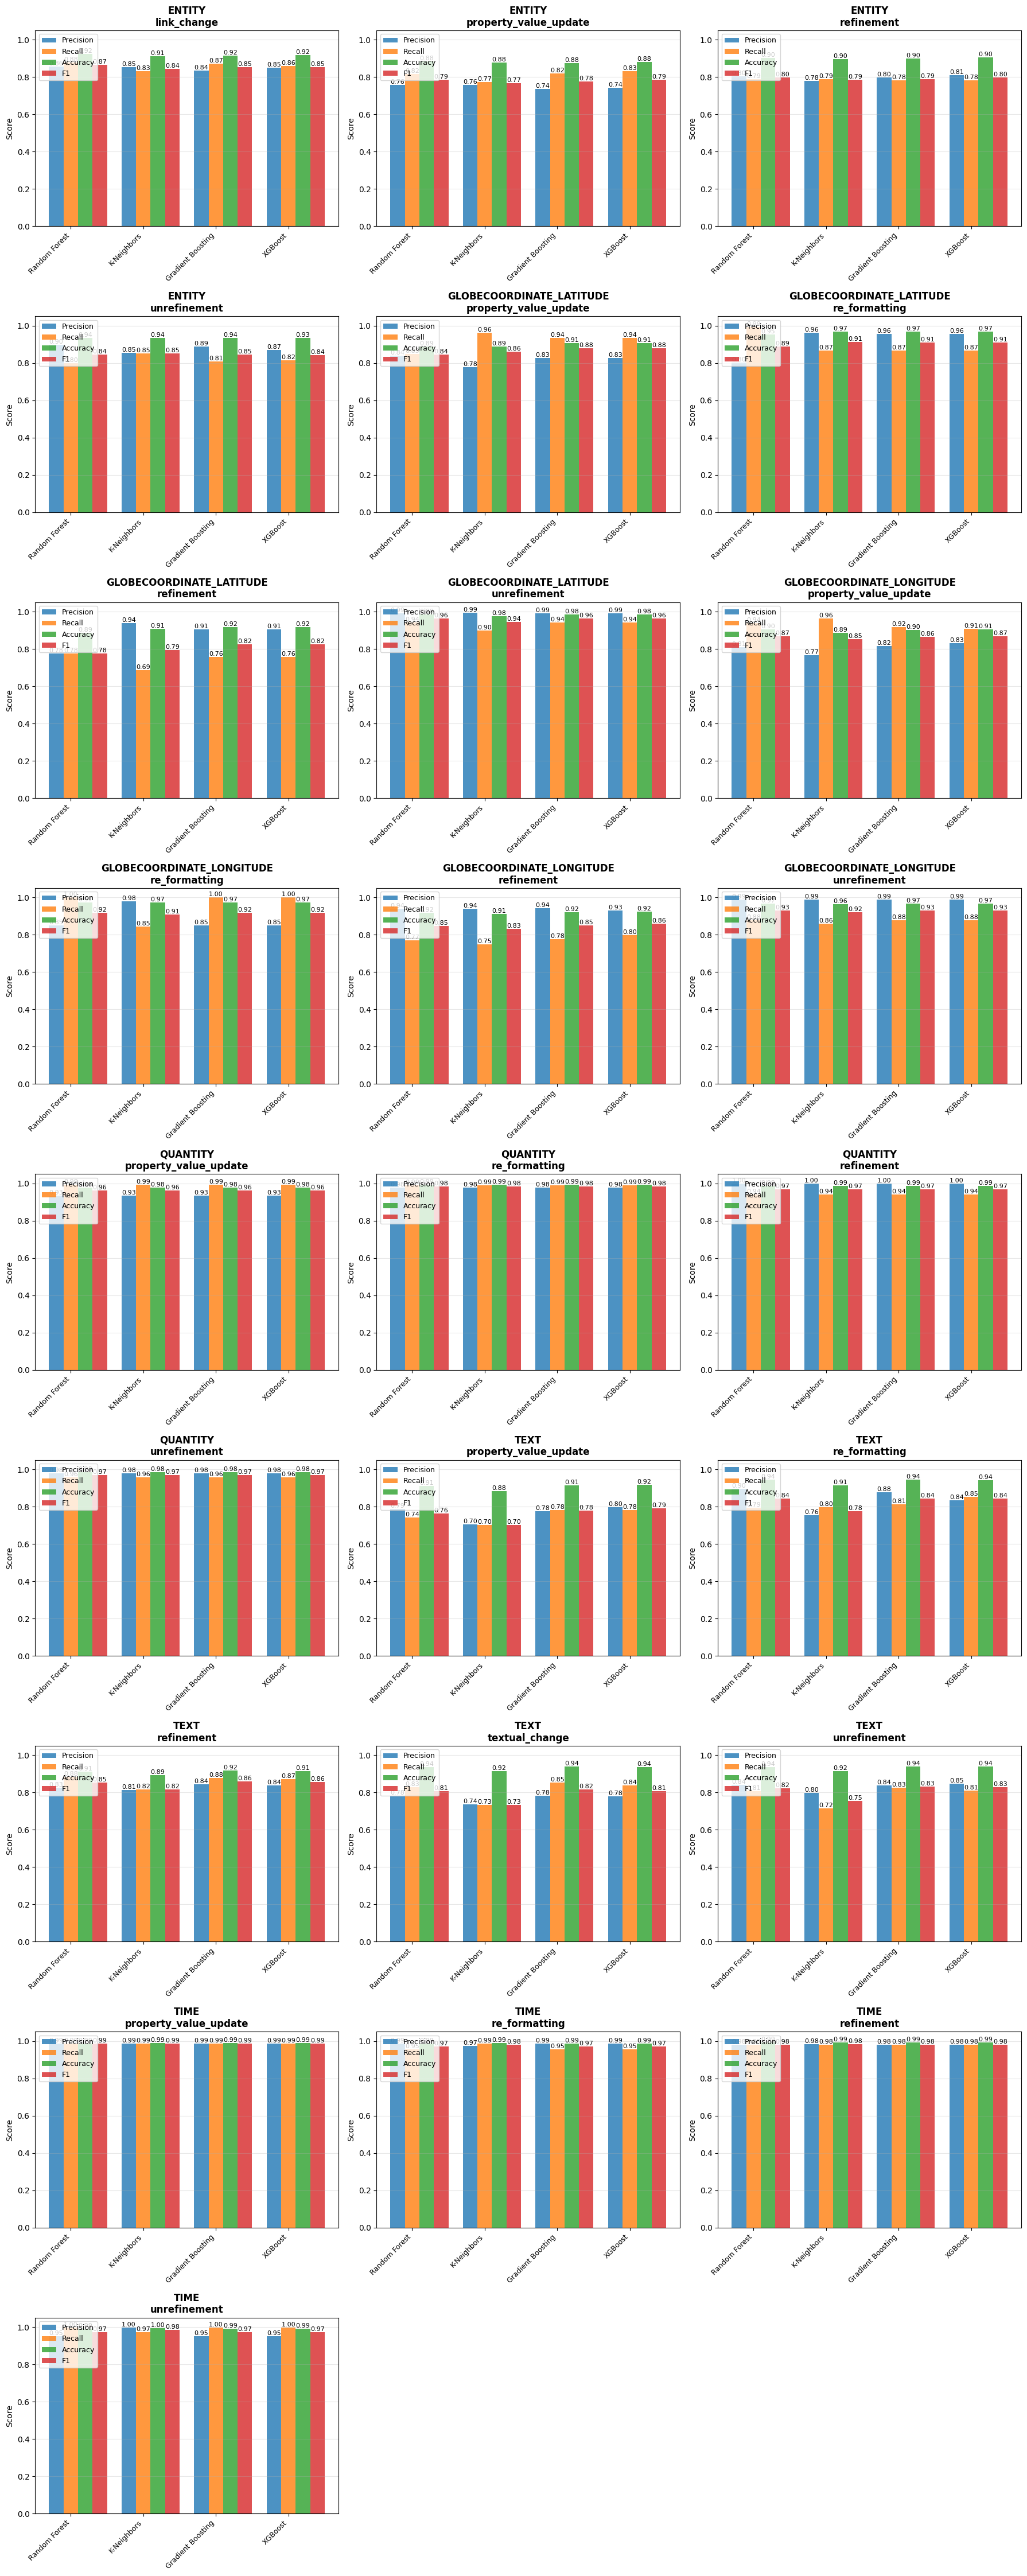

Model: kn F1: 0.85996 Datatype: globecoordinate_latitude Label: property_value_update
Model: random_forest F1: 0.84400 Datatype: globecoordinate_latitude Label: property_value_update
Model: gradient_boosting F1: 0.87759 Datatype: globecoordinate_latitude Label: property_value_update
Model: xgboost F1: 0.87759 Datatype: globecoordinate_latitude Label: property_value_update
Model: kn F1: 0.91242 Datatype: globecoordinate_latitude Label: re_formatting
Model: random_forest F1: 0.88735 Datatype: globecoordinate_latitude Label: re_formatting
Model: gradient_boosting F1: 0.91057 Datatype: globecoordinate_latitude Label: re_formatting
Model: xgboost F1: 0.91057 Datatype: globecoordinate_latitude Label: re_formatting
Model: kn F1: 0.79282 Datatype: globecoordinate_latitude Label: refinement
Model: random_forest F1: 0.77684 Datatype: globecoordinate_latitude Label: refinement
Model: gradient_boosting F1: 0.82462 Datatype: globecoordinate_latitude Label: refinement
Model: xgboost F1: 0.82462 Data

In [11]:

import pandas as pd

def plot_metrics(results_dt_label_model):
    models = ['random_forest', 'kn', 'gradient_boosting', 'xgboost']
    model_labels = ['Random Forest', 'K-Neighbors', 'Gradient Boosting', 'XGBoost']
    metrics = ['precision', 'recall', 'accuracy', 'f1']

    # Count subplots
    total_plots = sum(len(results_dt_label_model[dt]) for dt in results_dt_label_model)
    ncols = 3
    nrows = (total_plots + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5*nrows))
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    plot_idx = 0
    for datatype in sorted(results_dt_label_model.keys()):
        for label in sorted(results_dt_label_model[datatype].keys()):
            ax = axes[plot_idx]
            
            x = np.arange(len(models))
            width = 0.2
            
            for i, metric in enumerate(metrics):
                values = [results_dt_label_model[datatype][label][model][metric] for model in models] # metric (accuracy/precision/recall/f1) values for this label and datatype
                
                offset = (i - 1) * width
                bars = ax.bar(x + offset, values, width, label=metric.capitalize(), alpha=0.8)
                
                for bar in bars:
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.2f}',
                        ha='center', va='bottom', fontsize=8)
            
            ax.set_ylabel('Score')
            ax.set_title(f'{datatype.upper()}\n{label}', fontweight='bold', fontsize=12)
            ax.set_xticks(x)
            ax.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=9)
            ax.legend(loc='upper left', fontsize=9)
            ax.grid(axis='y', alpha=0.3)
            ax.set_ylim([0, 1.05])
            
            plot_idx += 1

    for idx in range(plot_idx, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.savefig('classifier_metrics_all.png', dpi=300, bbox_inches='tight')
    plt.show()

    # OVERALL: the best one seems to be gradient boosting, in some cases (not many) random forest does better

    ML_MODELS = ['kn', 'random_forest', 'gradient_boosting', 'xgboost']
    TRAINING_RESULTS = 'src/results/training'

    score_per_model = {}
    df_data = {
        'datatype': [],
        'label': [],
        'best_model': [],
        'best_f1': []
    }
    
    for datatype in results_dt_label_model:
        for label in results_dt_label_model[datatype]:
            best_f1 = -1
            best_models = []
            for model in results_dt_label_model[datatype][label]:
                if model not in score_per_model:
                    score_per_model[model] = 0
                
                f1 = results_dt_label_model[datatype][label][model]['f1']
                
                print(f'Model: {model}', f'F1: {f1:.5f}', 'Datatype:', datatype, 'Label:', label)
                
                if f1 > best_f1:
                    best_f1 = f1
                    best_models = [model] # reset with a new best model
                elif f1 == best_f1: # more than 1 model has best f1
                    best_models.append(model) 

            df_data['datatype'].append(datatype)
            df_data['label'].append(label)
            df_data['best_model'].append(', '.join(best_models))
            df_data['best_f1'].append(best_f1)
            
            for model in best_models:
                score_per_model[model] += 1

    df = pd.DataFrame(df_data)

    df.to_csv(f'{TRAINING_RESULTS}/best_model_per_f1_all_tasks.csv', header=0)
    print(f'Saved best model per classification task (according to F1 score) to {TRAINING_RESULTS}/best_model_per_f1_all_tasks.csv')

    print('Overall best model (considering only F1 score):')
    best_score = 0
    best_model = None
    for model, score in score_per_model.items():
        if score > best_score:
            best_score = score
            best_model = model
        print(f'Model: {model}, Score: {score}')
    
    model_averages = {model: {'f1': [], 'precision': [], 'recall': [], 'accuracy': []} 
                for model in ML_MODELS}

    for datatype in results_dt_label_model:
        for label in results_dt_label_model[datatype]:
            for model in ML_MODELS:
                model_averages[model]['f1'].append(results_dt_label_model[datatype][label][model]['f1'])
                model_averages[model]['precision'].append(results_dt_label_model[datatype][label][model]['precision'])
                model_averages[model]['recall'].append(results_dt_label_model[datatype][label][model]['recall'])
                model_averages[model]['accuracy'].append(results_dt_label_model[datatype][label][model]['accuracy'])


    summary_stats = []
    for model in ML_MODELS:
        summary_stats.append({
            'Model': model,
            'Mean F1': np.mean(model_averages[model]['f1']),
            'Mean Precision': np.mean(model_averages[model]['precision']),
            'Mean Recall': np.mean(model_averages[model]['recall']),
            'Mean Accuracy': np.mean(model_averages[model]['accuracy'])
        })

plot_metrics(results_dt_label_model_micro)